# Single-Parameter Convergence Diagnostic: Cloud Albedo vs. Full Trenberth Loss

**Motivation.** `trenberth_full.ipynb` calibrates 23 parameters against all 6 Trenberth
fluxes and does not convergence cleanly — its built-in parameter-count ablation
(stages of 4/8/15/18/20/23 params) already suggests instability grows with the number
of trained parameters. This notebook goes one step further and tests the extreme
minimal case: **a single parameter** (`cloud_albedo`) trained against the *full*
6-flux `TRENBERTH_LOSS`.

**Why this isolates the problem.** `cloud_albedo` only has a direct physical link to
the shortwave branch (mainly OSR, and indirectly SRU/SRD); it has no direct pathway to
the longwave fluxes (OLR, LRD, LRU). So this run can **never** hit `loss_threshold` —
5 of 6 flux residuals are structurally un-correctable by this parameter. That's fine;
it's not the point. The point is what the *optimization trajectory* looks like:

- If the loss decreases smoothly for the OSR-linked component and then **plateaus**
  (rather than diverging or oscillating), that says the online-gradient estimator,
  Enzyme AD, and the optimizer are all stable in isolation — and the non-convergence
  seen with 23 parameters is a dimensionality / parameter-interaction problem, not a
  generic instability in the training loop.
- If the loss **diverges, oscillates without bound, or the run NaNs out** even with a
  single parameter, that points to something more fundamental (LR too high for the
  online-gradient noise floor, batch/aliasing settings, or an AD correctness issue)
  that would also be corrupting every multi-parameter run.

Config below reuses the corrected hyperparameters from `trenberth_full.ipynb`
(`batch_days=10`, `samples_per_batch=32`, `Adam(1f-2)`, `daily_cycle=true`) so results
are directly comparable to that notebook's ablation stages.

## 1. Setup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using SpeedyCalibration
using Optimisers
using CairoMakie
using GeoMakie
using Dates
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`


## 2. Define the Single Trainable Parameter

Only `cloud_albedo` — the same path and bounds as in `trenberth_full.ipynb`, so the
starting point is identical to that notebook's stage-1 ablation parameter.

In [3]:
param_specs = [
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
]

1-element Vector{ParamSpec}:
 ParamSpec(:cloud_albedo, [:shortwave_radiation, :clouds, :cloud_albedo], (0.25f0, 0.95f0), 0.6f0, 1.0f0)

## 3. Loss: Full 6-Flux Trenberth Target

Deliberately using the *full* `TRENBERTH_LOSS`, not an OSR-only loss — the point is to
see how a single free parameter behaves under the same loss surface that the full
23-parameter run struggles with, not to give it an easier problem.

In [4]:
loss_config = TRENBERTH_LOSS

println("Loss configuration: $(length(loss_config.flux_keys))-flux MSE")
println()
@printf("  %-6s  %8s  %6s\n", "flux", "target", "weight")
println("  " * "-" ^ 24)
for k in loss_config.flux_keys
    @printf("  %-6s  %6.1f W/m²  %.1f\n",
            k, loss_config.targets[k], loss_config.weights[k])
end

Loss configuration: 6-flux MSE

  flux      target  weight
  ------------------------
  osr      101.9 W/m²  1.0
  sru       23.0 W/m²  0.5
  srd      168.0 W/m²  0.5
  olr      235.0 W/m²  1.0
  lrd      333.0 W/m²  0.3
  lru      398.0 W/m²  0.3


## 4. Quick Test

Verify the parameter path resolves and Enzyme differentiates through it cleanly
before committing to a long run.

In [5]:
# dt=Minute(20): same override used in trenberth_full.ipynb -- the auto-scaled Δt at
# trunc=5 is too large to stay numerically stable with the full physics package.
result_test = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    quick_test_config(dt=Minute(20)),
)

println("Quick test complete: ", result_test.conv_info.stop_reason)

g = result_test.history[:grad_cloud_albedo]
println("\ncloud_albedo gradient magnitude (last batch): ", abs(g[end]))

[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=0.50
   srd  target= 168.0 W/m²  weight=0.50
   olr  target= 235.0 W/m²  weight=1.00
   lrd  target= 333.0 W/m²  weight=0.30
   lru  target= 398.0 W/m²  weight=0.30
----------------------------------------------------------------------
LR: 1.00e-02 | grad_clip: 5.00 | samples/batch: 20 | loss_threshold: 500.00
(sigmoid reparameterisation active)

Spinup (5 days)...


   0%  ETA: 0:30:00 (2000-03-23,  4.80 millenia/day,  33 m/s, [ -53,   19] ˚C)

Spinup complete in 15.3 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 216.8 s.


   0%  ETA: 197.65 days (2000-03-26, 184.64 days/day,  32 m/s, [ -54,   17] ˚C)

...

Batch   3 | LR 1.0e-02 | osr=112.9 sru= 22.1 srd=194.4 olr=241.9 lrd=298.5 lru=397.6 | L̄  1083.84 | Δp 2.9e-03


   0%  ETA: 61.43 days (2000-04-06, 593.95 days/day,  35 m/s, [ -57,   11] ˚C)

Batch   4 | LR 1.0e-02 | osr=107.1 sru= 23.0 srd=205.1 olr=235.8 lrd=291.9 lru=397.2 | L̄  1119.02 | Δp 2.9e-03


   0%  ETA: 49.89 days (2000-04-09,  2.00 years/day,  36 m/s, [ -58,    9] ˚C)

Batch   5 | LR 1.0e-02 | osr=104.3 sru= 23.6 srd=212.2 olr=230.3 lrd=286.1 lru=397.3 | L̄  1228.55 | Δp 1.2e-03

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.5939
----------------------------------------------------------------------
  Final osr : 104.26 W/m²  (target: 101.9)
  Final sru :  23.60 W/m²  (target: 23.0)
  Final srd : 212.22 W/m²  (target: 168.0)
  Final olr : 230.29 W/m²  (target: 235.0)
  Final lrd : 286.07 W/m²  (target: 333.0)
  Final lru : 397.29 W/m²  (target: 398.0)
Final smoothed loss: 1228.5450  |  best: 1083.8398
Stop: max batches reached  |  time: 2357.8 s

NOTE: final batch (5, loss=1228.55) is worse than best batch (3, loss=1083.8398).
      Use `result.best_params` instead of `result.final_params` to recover the best checkpoint.
Quick test complete: max batches reached

cloud_albedo gradient magnitude (last batch): 747.98413


---

## 5. Full Training Run

Same hyperparameters as the (corrected) full-23-parameter run in
`trenberth_full.ipynb`: `batch_days=10`, `samples_per_batch=32` (chosen to avoid
diurnal-cycle aliasing at `trunc=31`), `Adam(1f-2)`, `daily_cycle=true`.

`loss_threshold` is set to an unreachable `1f-6` — as in that notebook's ablation
section — so the run is **never** stopped by "convergence" and we can watch the full
trajectory play out under `patience`-based early stopping instead. This gives a clean
read on whether the loss trajectory itself is stable, independent of where any
arbitrary threshold happens to sit.

In [17]:
result = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    TrainingConfig(
        spinup_days       = 180,
        batch_days        = 10.0,
        samples_per_batch = 32,
        max_batches       = 300,
        loss_threshold    = 1f-6,   # disabled: always run to convergence/patience limit
        trunc             = 31,
        nlayers           = 8,
        daily_cycle       = true,   # required: physical diurnal cycle must stay on
    ),
    save_dir = joinpath(@__DIR__, "output", "cloud_albedo_only"),
)

SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=0.50
   srd  target= 168.0 W/m²  weight=0.50
   olr  target= 235.0 W/m²  weight=1.00
   lrd  target= 333.0 W/m²  weight=0.30
   lru  target= 398.0 W/m²  weight=0.30
----------------------------------------------------------------------
LR: 1.00e-02 | grad_clip: 5.00 | samples/batch: 32 | loss_threshold: 0.00
(sigmoid reparameterisation active)

Spinup (180 days)...


   0%  ETA: 4:11:02 (2000-09-16, 570.82 years/day, 109 m/s, [ -87,   29] ˚C)m

Spinup complete in 74.7 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.2 s.


   0%  ETA: 4:11:50 (2000-09-17, 568.97 years/day, 106 m/s, [ -87,   29] ˚C)

Starting training...
----------------------------------------------------------------------


...

   9%  ETA: 9:10:02 (2008-10-14, 239.35 years/day,  99 m/s, [-115,   29] ˚C)

Batch 295 | LR 2.5e-03 | osr=108.2 sru= 24.3 srd=182.4 olr=242.5 lrd=317.2 lru=383.5 | L̄   341.41 | Δp 1.5e-05


   9%  ETA: 9:09:34 (2008-12-03, 239.19 years/day,  95 m/s, [-102,   29] ˚C)

  ↓ LR: 2.50e-03 → 1.25e-03 (decay #3)
Batch 300 | LR 1.2e-03 | osr=107.7 sru= 24.4 srd=182.4 olr=243.6 lrd=318.5 lru=383.7 | L̄   343.81 | Δp 1.9e-04

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.7898
----------------------------------------------------------------------
  Final osr : 107.69 W/m²  (target: 101.9)
  Final sru :  24.39 W/m²  (target: 23.0)
  Final srd : 182.41 W/m²  (target: 168.0)
  Final olr : 243.61 W/m²  (target: 235.0)
  Final lrd : 318.45 W/m²  (target: 333.0)
  Final lru : 383.66 W/m²  (target: 398.0)
Final smoothed loss: 343.8120  |  best: 322.1321
Stop: max batches reached  |  time: 3147.0 s

NOTE: final batch (300, loss=343.81) is worse than best batch (150, loss=322.1321).
      Use `result.best_params` instead of `result.final_params` to recover the best checkpoint.


TrainingResult(300 batches, stop=max batches reached, best_loss=322.1321)

## 6. Inspect Results

In [7]:
println(result)
println()
println("Convergence info:")
println("  stop_reason:        ", result.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2))
println("  best_batch:         ", result.conv_info.best_batch)
println("  total_batches:      ", result.conv_info.total_batches)
@printf("  total_time:         %.1f hours\n", result.conv_info.total_time / 3600)

TrainingResult(150 batches, stop=max batches reached, best_loss=322.1321)

Convergence info:
  stop_reason:        max batches reached
  best_smoothed_loss: 322.13
  best_batch:         150
  total_batches:      150
  total_time:         0.5 hours


In [8]:
@printf("\n%-14s  %10s  %10s  %10s\n", "parameter", "initial", "trained", "change")
println("-" ^ 50)
for spec in result.param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result.final_params[spec.name]
    @printf("%-14s  %10.4g  %10.4g  %+10.4g\n",
            spec.name, init, trained, trained - init)
end


parameter          initial     trained      change
--------------------------------------------------
cloud_albedo           0.6      0.7921     +0.1921


In [9]:
# Flux bias at end of training -- expect OSR (and to a lesser extent SRU/SRD) to
# move toward target, and OLR/LRD/LRU to stay roughly at their default bias since
# cloud_albedo has no direct pathway to the longwave branch.
@printf("\n%-6s  %8s  %8s  %8s\n", "flux", "target", "trained", "bias")
println("-" ^ 38)
for k in result.loss_config.flux_keys
    tgt  = result.loss_config.targets[k]
    val  = result.history[k][end]
    @printf("%-6s  %8.2f  %8.2f  %+8.2f\n", k, tgt, val, val - tgt)
end


flux      target   trained      bias
--------------------------------------
osr       101.90    106.46     +4.56
sru        23.00     23.73     +0.73
srd       168.00    180.60    +12.60
olr       235.00    246.38    +11.38
lrd       333.00    320.60    -12.40
lru       398.00    385.77    -12.23


## 7. Plot Training History

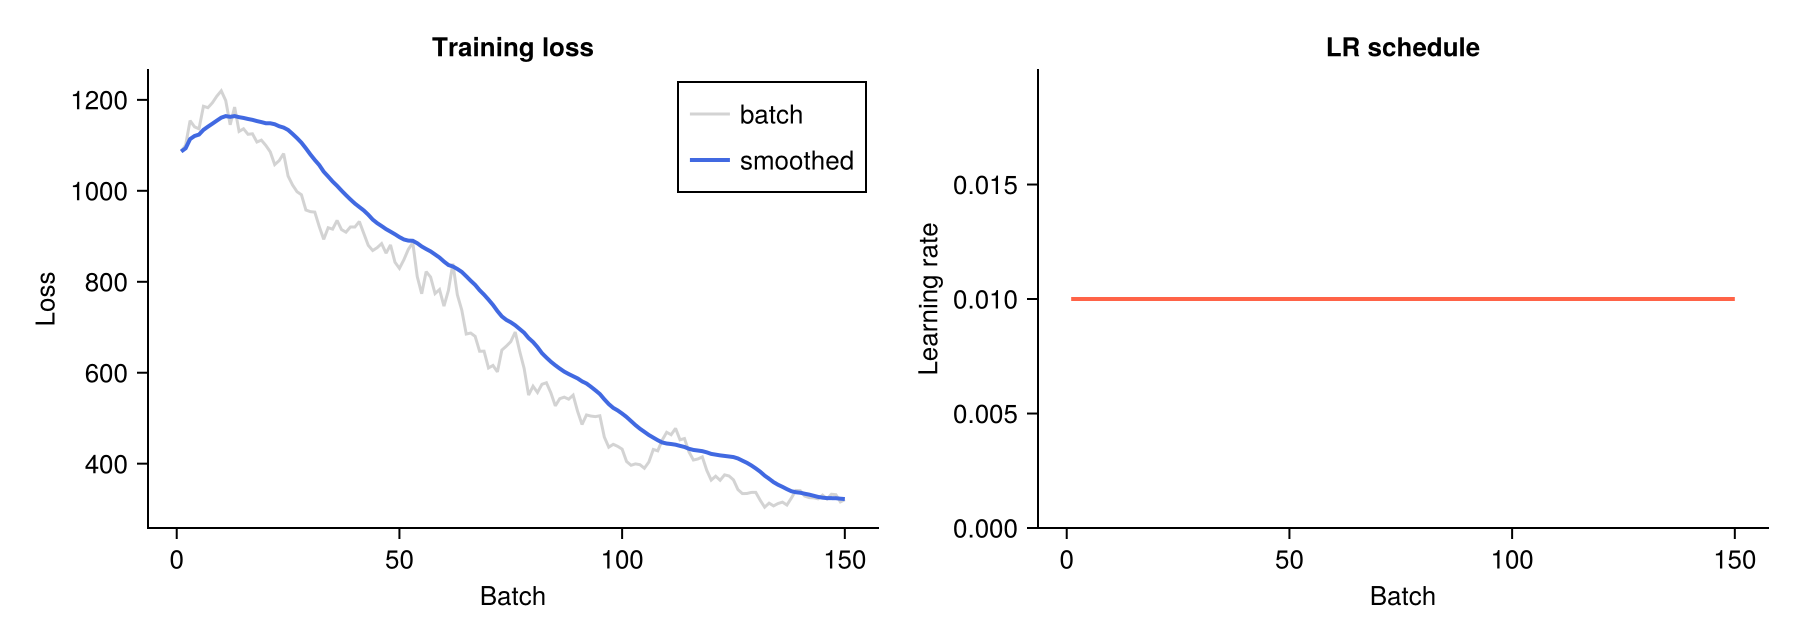

In [10]:
figs = plot_training(result; save_dir=joinpath(@__DIR__, "output", "cloud_albedo_only"))
figs.fig_loss

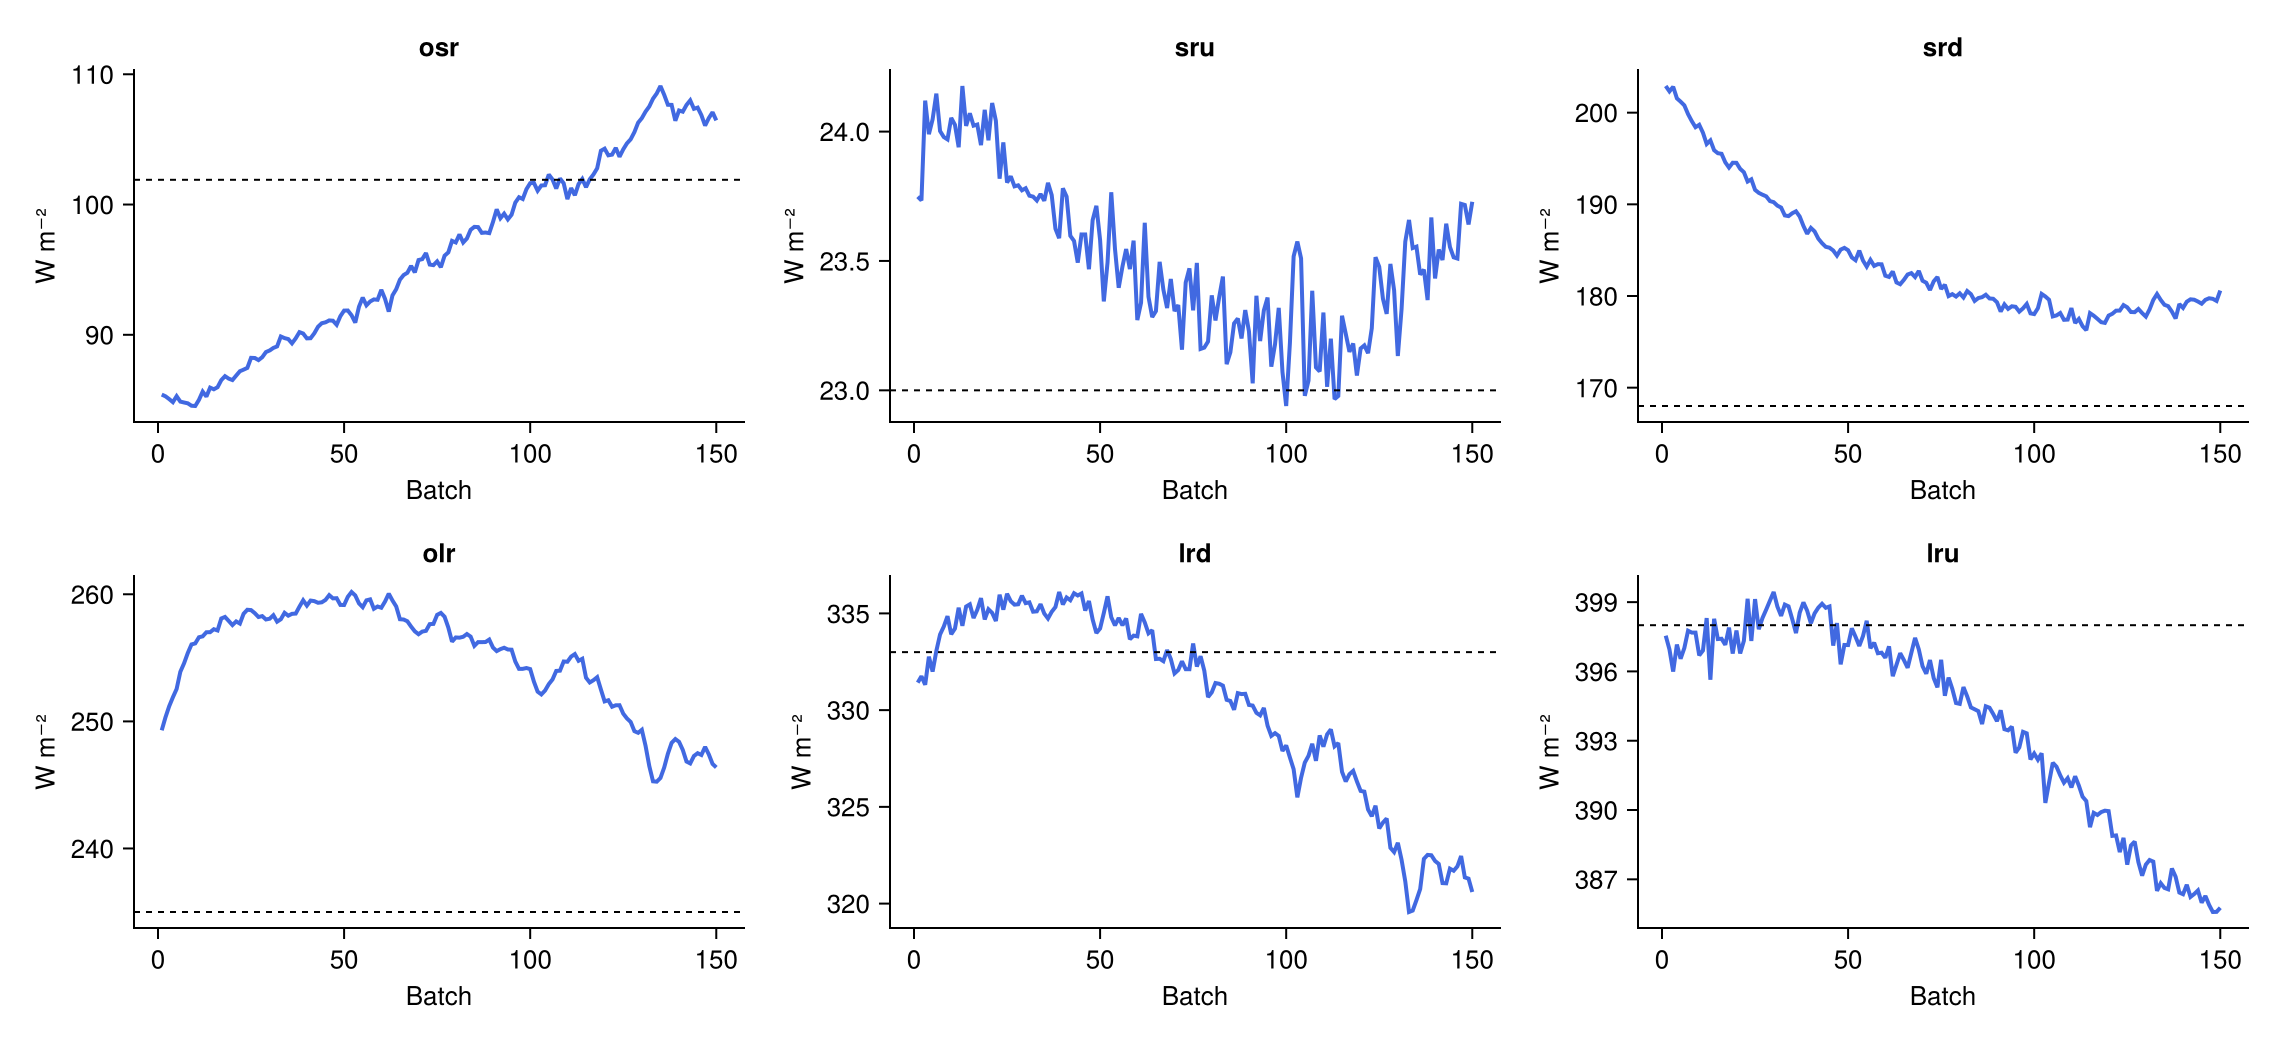

In [11]:
figs.fig_flux

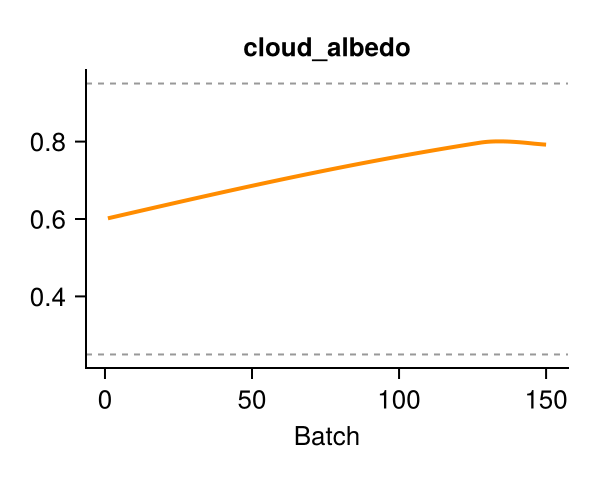

In [12]:
figs.fig_params

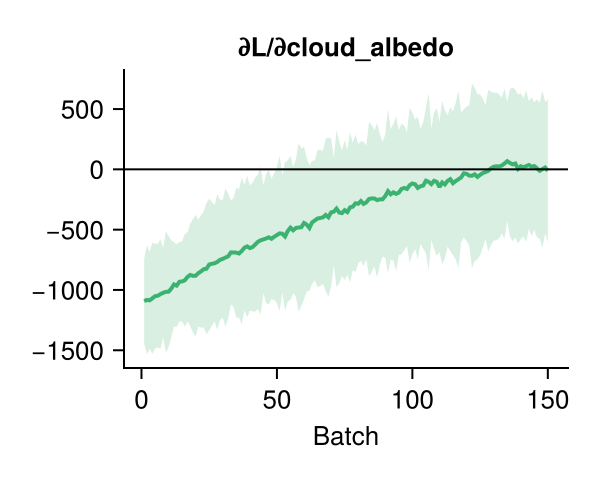

In [13]:
figs.fig_grads

## 8. Climate Validation

Compare the default vs. trained model's equilibrium climatology across all 6 target
fluxes. This is the clearest check of the "no pathway to longwave" hypothesis: the
LW fluxes (OLR, LRD, LRU) should show essentially unchanged bias from default.

In [14]:
clm = run_climate_validation(result; n_years=7, stat_years=5, dt=Minute(20))

Climate run: default ...


 100% Time: 1:32:13 (2007-03-20, 109.30 years/day,  99 m/s, [-102,   44] ˚C)


Climate run: trained ...


 100% Time: 4:24:23 (2007-03-20, 38.12 years/day, 100 m/s, [-114,   28] ˚C)m


(default = (osr = 72.846504f0, olr = 272.45572f0, srd = 177.56392f0, sru = 17.853838f0, lrd = 341.8073f0, lru = 399.00992f0, precip_total = 3.2176092f0, temp_profile = Float32[254.33943, 245.0881, 246.5963, 250.99757, 259.19992, 266.8099, 273.2447, 279.63647]), trained = (osr = 102.02332f0, olr = 244.49753f0, srd = 183.1683f0, sru = 19.22803f0, lrd = 320.19324f0, lru = 383.78424f0, precip_total = 3.0086787f0, temp_profile = Float32[237.6937, 232.47932, 235.38017, 243.27919, 253.01396, 261.40924, 268.4585, 275.42157]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lrd, lru, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter:

In [15]:
targets = result.loss_config.targets

@printf("%-6s  %8s  %9s  %9s  %9s  %9s\n",
        "flux", "target",
        "def val", "def bias",
        "trn val", "trn bias")
println("-" ^ 60)
for k in result.loss_config.flux_keys
    tgt    = targets[k]
    d_val  = getproperty(clm.default, k)
    t_val  = getproperty(clm.trained, k)
    @printf("%-6s  %8.2f  %9.2f  %+9.2f  %9.2f  %+9.2f\n",
            k, tgt, d_val, d_val-tgt, t_val, t_val-tgt)
end

flux      target    def val   def bias    trn val   trn bias
------------------------------------------------------------
osr       101.90      72.85     -29.05     102.02      +0.12
sru        23.00      17.85      -5.15      19.23      -3.77
srd       168.00     177.56      +9.56     183.17     +15.17
olr       235.00     272.46     +37.46     244.50      +9.50
lrd       333.00     341.81      +8.81     320.19     -12.81
lru       398.00     399.01      +1.01     383.78     -14.22


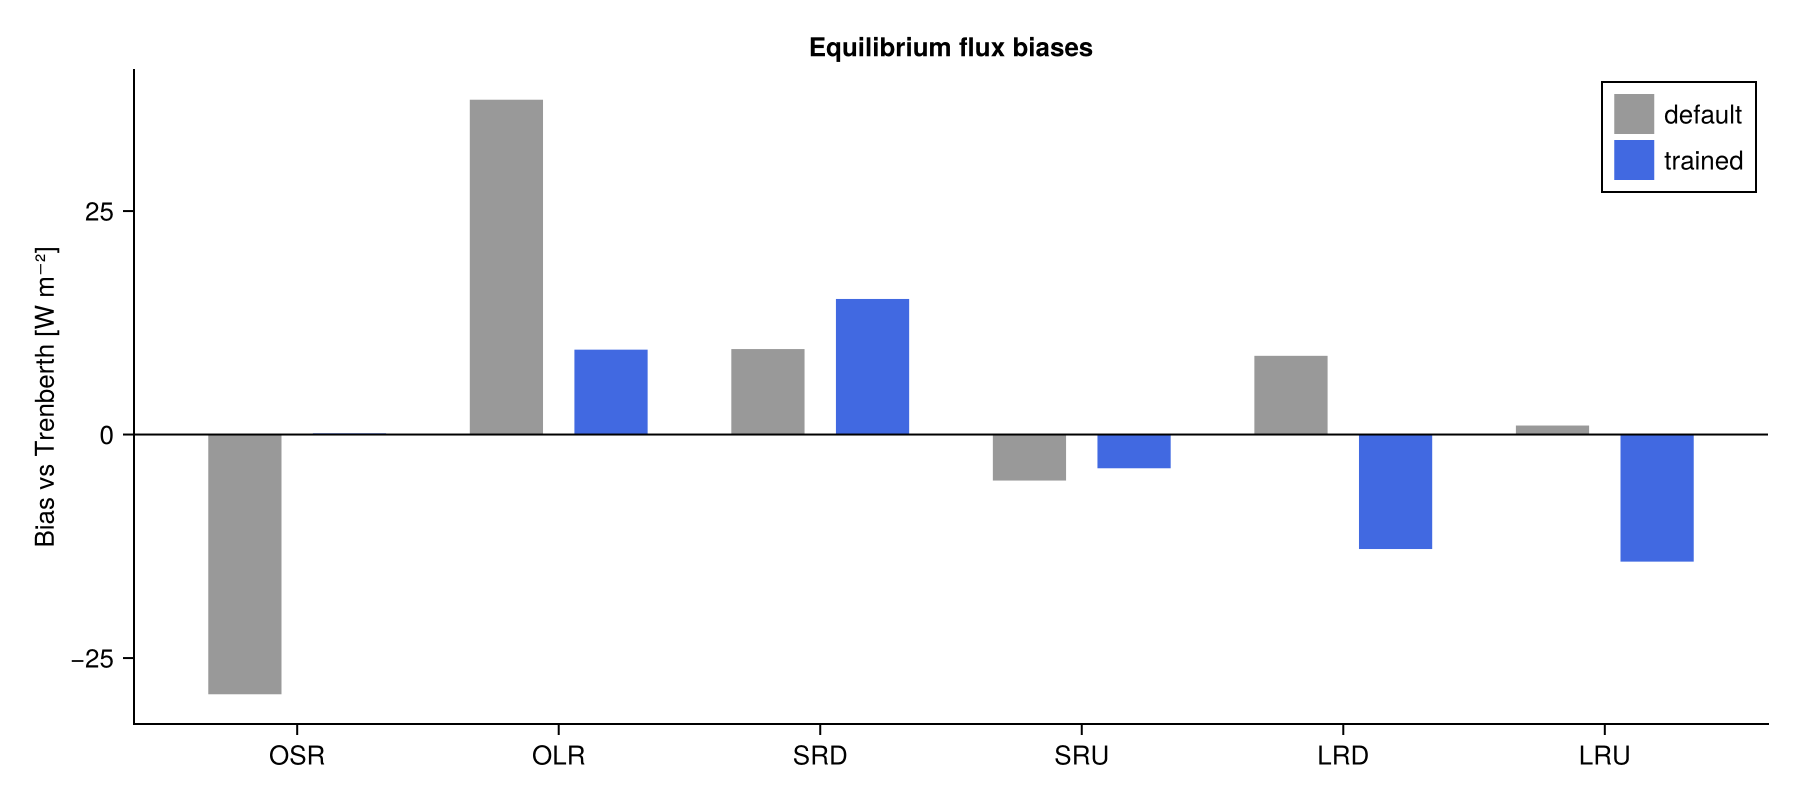

In [16]:
cfigs = plot_climate(clm;
    save_dir    = joinpath(@__DIR__, "output", "cloud_albedo_only"),
    loss_config = result.loss_config,
)
cfigs.fig_summary

## 9. Interpretation

Fill in after running:

- **Loss trajectory shape** (Section 5/7): smooth decay + plateau, or
  divergence/oscillation?
- **Which fluxes moved** (Section 6/8): did only OSR/SRU/SRD respond, confirming
  `cloud_albedo` has no meaningful longwave pathway?
- **Verdict**: if this single-parameter run is stable, the 23-parameter instability in
  `trenberth_full.ipynb` is a dimensionality/interaction effect — worth following up
  with a 2- or 3-parameter version of this notebook (e.g. add
  `stratocumulus_cover_max`, `stratocumulus_albedo`) to find where instability first
  appears, rather than jumping straight to the full 23-parameter ablation stages.

## 10. Follow-up: Does the Loss *Weighting* Explain the Floor?

`TRENBERTH_LOSS` deliberately down-weights the surface fluxes relative to OSR/OLR
(`weights = 1.0, 0.5, 0.5, 1.0, 0.3, 0.3`), reflecting that Trenberth et al. (2009)
report larger observational uncertainty on the surface terms than on the two
top-of-atmosphere terms. In Section 6/8's loss-floor decomposition (~322 total), the
two low-weight longwave surface terms LRD and LRU (weight 0.3 each) already had large
*absolute* biases (roughly -12 W/m² each) but a correspondingly small *loss
contribution*, purely because of their low weight. SRD (weight 0.5) similarly had a
sizeable bias but a damped contribution.

This section re-runs the exact same single-parameter (`cloud_albedo`) calibration
with the **same targets but all six weights set to 1.0** — every flux's raw squared
bias counts equally, instead of being pre-weighted by (assumed) observational
confidence. This isolates whether `TRENBERTH_LOSS`'s specific weighting scheme was
materially shaping where the single-parameter optimum landed and how large the
residual floor was, or whether a similar trade-off point (and a similarly
"mostly-unreachable-by-cloud_albedo" floor) emerges regardless of the weights.

In [18]:
loss_config_equal = LossConfig(
    [:osr, :sru, :srd, :olr, :lrd, :lru];
    targets = TRENBERTH_LOSS.targets,
    weights = Dict(:osr => 1.0f0, :sru => 1.0f0, :srd => 1.0f0,
                   :olr => 1.0f0, :lrd => 1.0f0, :lru => 1.0f0),
)

println("Loss configuration: $(length(loss_config_equal.flux_keys))-flux MSE (equal weights)")
println()
@printf("  %-6s  %8s  %6s\n", "flux", "target", "weight")
println("  " * "-" ^ 24)
for k in loss_config_equal.flux_keys
    @printf("  %-6s  %6.1f W/m²  %.1f\n",
            k, loss_config_equal.targets[k], loss_config_equal.weights[k])
end

Loss configuration: 6-flux MSE (equal weights)

  flux      target  weight
  ------------------------
  osr      101.9 W/m²  1.0
  sru       23.0 W/m²  1.0
  srd      168.0 W/m²  1.0
  olr      235.0 W/m²  1.0
  lrd      333.0 W/m²  1.0
  lru      398.0 W/m²  1.0


### Full Training Run (Equal Weights)

Same hyperparameters as Section 5 (`batch_days=10`, `samples_per_batch=32`,
`Adam(1f-2)`, `daily_cycle=true`). `max_batches=150`: Section 5's follow-up extension
to 300 batches showed the run had already found its stable optimum by ~batch 150 and
gained nothing from the extra budget (loss never beat its batch-150 record, and all 3
LR decays fired without un-sticking it) — so we don't repeat that mistake here.

In [19]:
result_eq = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config_equal,
    TrainingConfig(
        spinup_days       = 180,
        batch_days        = 10.0,
        samples_per_batch = 32,
        max_batches       = 150,
        loss_threshold    = 1f-6,   # disabled: always run to convergence/patience limit
        trunc             = 31,
        nlayers           = 8,
        daily_cycle       = true,   # required: physical diurnal cycle must stay on
    ),
    save_dir = joinpath(@__DIR__, "output", "cloud_albedo_equal_weights"),
)

SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=1.00
   srd  target= 168.0 W/m²  weight=1.00
   olr  target= 235.0 W/m²  weight=1.00
   lrd  target= 333.0 W/m²  weight=1.00
   lru  target= 398.0 W/m²  weight=1.00
----------------------------------------------------------------------
LR: 1.00e-02 | grad_clip: 5.00 | samples/batch: 32 | loss_threshold: 0.00
(sigmoid reparameterisation active)

Spinup (180 days)...


   0%  ETA: 3:44:53 (2000-09-16, 637.16 years/day, 109 m/s, [ -87,   29] ˚C)

Spinup complete in 66.9 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.2 s.


   0%  ETA: 3:45:40 (2000-09-17, 634.95 years/day, 106 m/s, [ -88,   27] ˚C)

Starting training...
----------------------------------------------------------------------


...

   4%  ETA: 4 days, 10:43:14 (2004-09-05, 21.48 years/day, 111 m/s, [-104,   31] ˚C)

Batch 145 | LR 1.0e-02 | osr=108.7 sru= 23.5 srd=178.1 olr=247.3 lrd=321.3 lru=385.0 | L̄   557.28 | Δp 1.3e-03


   5%  ETA: 4 days, 7:41:16 (2004-10-25, 22.08 years/day, 105 m/s, [-109,   29] ˚C)m

Batch 150 | LR 1.0e-02 | osr=109.8 sru= 23.6 srd=179.0 olr=245.4 lrd=319.7 lru=385.1 | L̄   581.67 | Δp 1.1e-03

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.8217
----------------------------------------------------------------------
  Final osr : 109.84 W/m²  (target: 101.9)
  Final sru :  23.61 W/m²  (target: 23.0)
  Final srd : 179.02 W/m²  (target: 168.0)
  Final olr : 245.41 W/m²  (target: 235.0)
  Final lrd : 319.72 W/m²  (target: 333.0)
  Final lru : 385.06 W/m²  (target: 398.0)
Final smoothed loss: 581.6665  |  best: 530.5367
Stop: max batches reached  |  time: 18007.5 s

NOTE: final batch (150, loss=581.67) is worse than best batch (132, loss=530.5367).
      Use `result.best_params` instead of `result.final_params` to recover the best checkpoint.


TrainingResult(150 batches, stop=max batches reached, best_loss=530.5367)

### Inspect Results (Equal Weights)

In [20]:
println(result_eq)
println()
println("Convergence info:")
println("  stop_reason:        ", result_eq.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result_eq.conv_info.best_smoothed_loss, digits=2))
println("  best_batch:         ", result_eq.conv_info.best_batch)
println("  total_batches:      ", result_eq.conv_info.total_batches)

# Use best_params, not final_params -- Section 5 showed the final batch can land
# past the optimum once LR-decay/patience have kicked in.
@printf("\n%-14s  %10s  %10s  %10s\n", "parameter", "initial", "trained (best)", "change")
println("-" ^ 55)
for spec in result_eq.param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result_eq.best_params[spec.name]
    @printf("%-14s  %10.4g  %10.4g  %+10.4g\n",
            spec.name, init, trained, trained - init)
end

TrainingResult(150 batches, stop=max batches reached, best_loss=530.5367)

Convergence info:
  stop_reason:        max batches reached
  best_smoothed_loss: 530.54
  best_batch:         132
  total_batches:      150

parameter          initial  trained (best)      change
-------------------------------------------------------
cloud_albedo           0.6      0.8013     +0.2013


In [21]:
# Flux bias at the *best* batch (not necessarily the final batch -- see above).
bb = result_eq.conv_info.best_batch
@printf("\n%-6s  %8s  %8s  %8s\n", "flux", "target", "at best", "bias")
println("-" ^ 38)
for k in result_eq.loss_config.flux_keys
    tgt  = result_eq.loss_config.targets[k]
    val  = result_eq.history[k][bb]
    @printf("%-6s  %8.2f  %8.2f  %+8.2f\n", k, tgt, val, val - tgt)
end


flux      target   at best      bias
--------------------------------------
osr       101.90    107.68     +5.78
sru        23.00     23.56     +0.56
srd       168.00    179.45    +11.45
olr       235.00    246.48    +11.48
lrd       333.00    321.13    -11.87
lru       398.00    387.75    -10.25


### Plot Training History (Equal Weights)

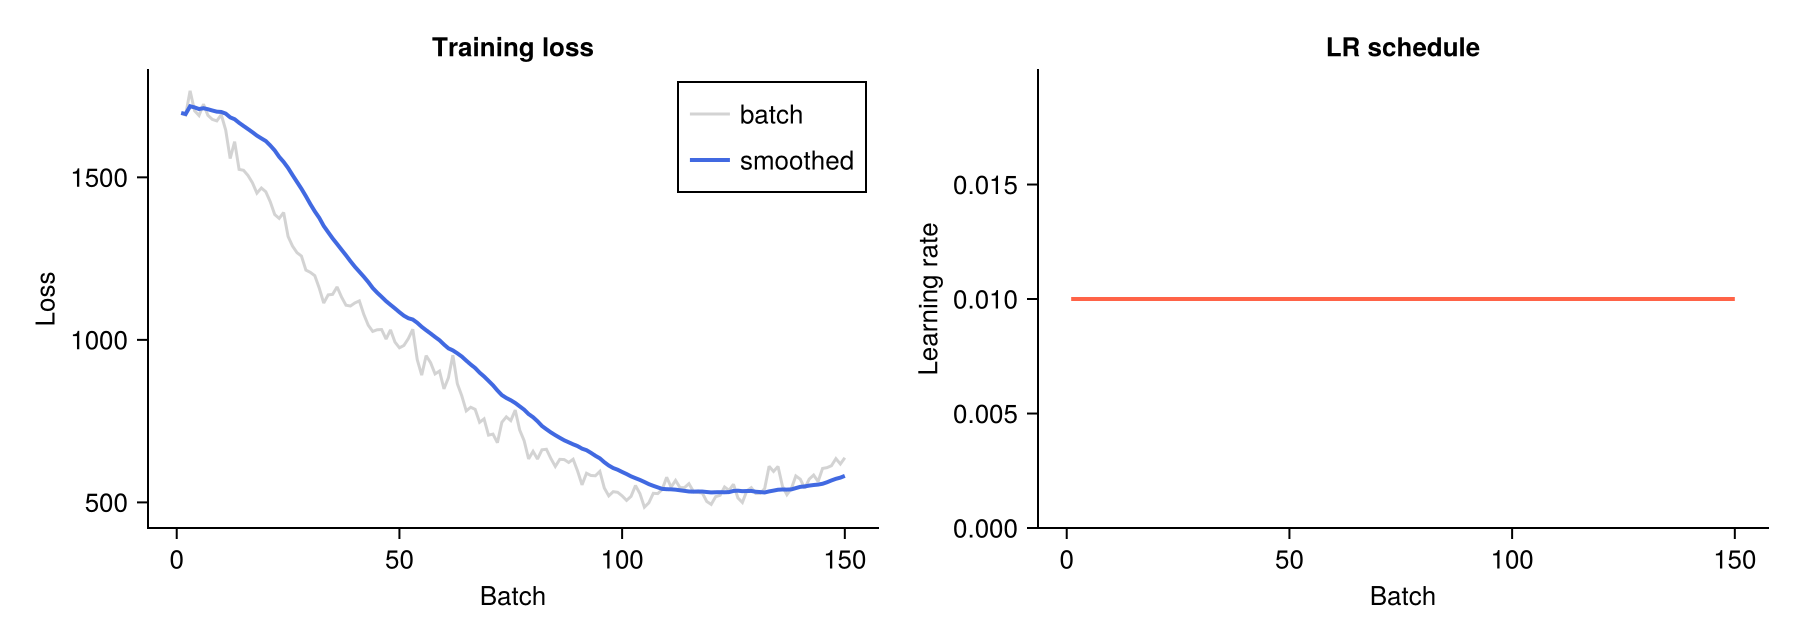

In [22]:
figs_eq = plot_training(result_eq; save_dir=joinpath(@__DIR__, "output", "cloud_albedo_equal_weights"))
figs_eq.fig_loss

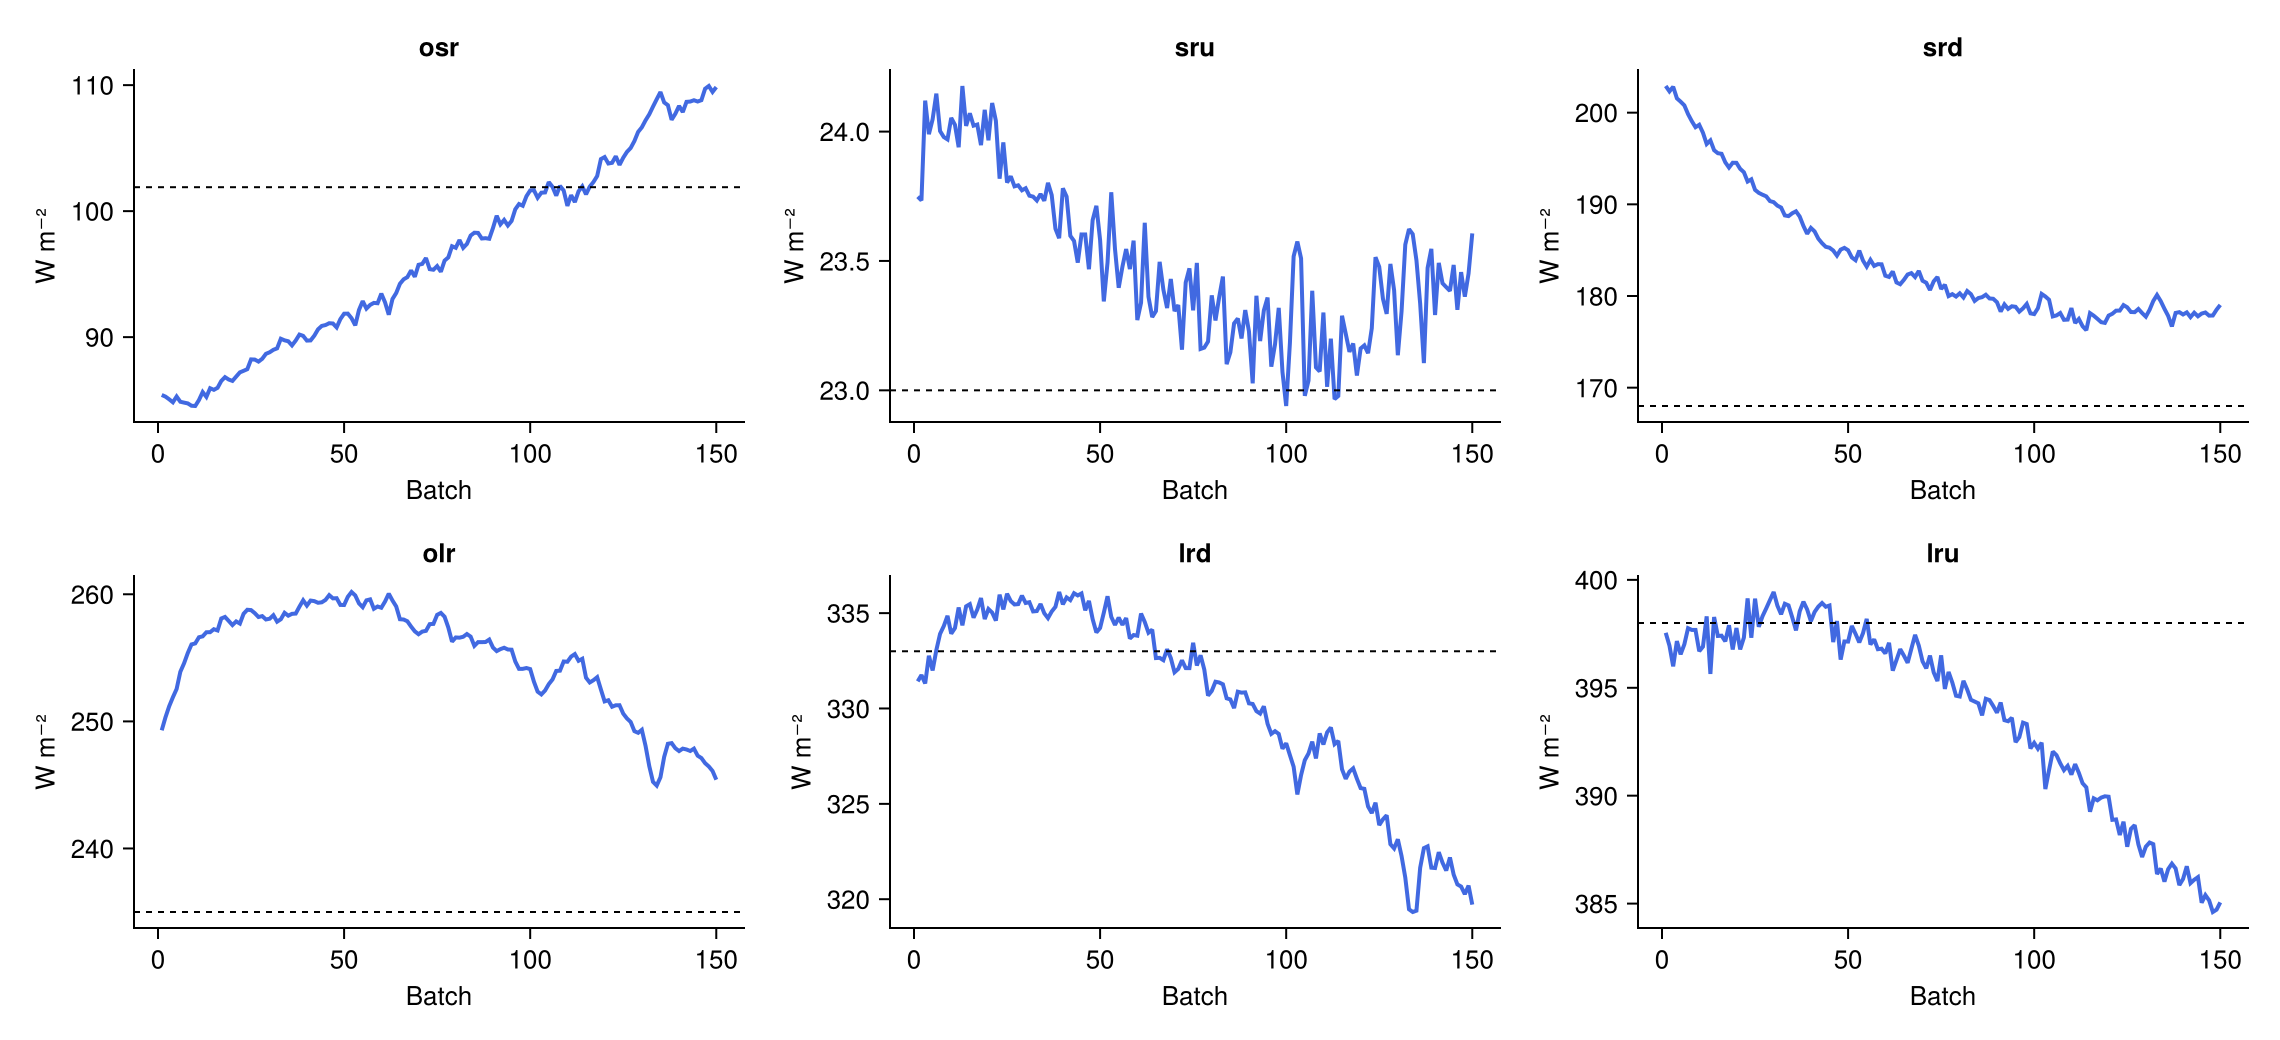

In [23]:
figs_eq.fig_flux

### Climate Validation (Equal Weights)

**⏱ Expected runtime: ~1–3 hours at T31.**

In [24]:
clm_eq = run_climate_validation(result_eq; n_years=7, stat_years=5, dt=Minute(20))

Climate run: default ...


 100% Time: 2:22:09 (2007-03-20, 70.91 years/day,  99 m/s, [-102,   44] ˚C)m


Climate run: trained ...


 100% Time: 1:15:23 (2007-03-20, 133.70 years/day,  97 m/s, [-113,   33] ˚C)


(default = (osr = 72.846504f0, olr = 272.45572f0, srd = 177.56392f0, sru = 17.853838f0, lrd = 341.8073f0, lru = 399.00992f0, precip_total = 3.2176092f0, temp_profile = Float32[254.33943, 245.0881, 246.5963, 250.99757, 259.19992, 266.8099, 273.2447, 279.63647]), trained = (osr = 106.95537f0, olr = 240.07753f0, srd = 183.22227f0, sru = 19.41305f0, lrd = 316.462f0, lru = 381.17114f0, precip_total = 2.9567778f0, temp_profile = Float32[236.15756, 230.62924, 233.08289, 241.9117, 251.90057, 260.44733, 267.6159, 274.671]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lrd, lru, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::In

In [25]:
targets_eq = result_eq.loss_config.targets

@printf("%-6s  %8s  %9s  %9s  %9s  %9s\n",
        "flux", "target",
        "def val", "def bias",
        "trn val", "trn bias")
println("-" ^ 60)
for k in result_eq.loss_config.flux_keys
    tgt    = targets_eq[k]
    d_val  = getproperty(clm_eq.default, k)
    t_val  = getproperty(clm_eq.trained, k)
    @printf("%-6s  %8.2f  %9.2f  %+9.2f  %9.2f  %+9.2f\n",
            k, tgt, d_val, d_val-tgt, t_val, t_val-tgt)
end

flux      target    def val   def bias    trn val   trn bias
------------------------------------------------------------
osr       101.90      72.85     -29.05     106.96      +5.06
sru        23.00      17.85      -5.15      19.41      -3.59
srd       168.00     177.56      +9.56     183.22     +15.22
olr       235.00     272.46     +37.46     240.08      +5.08
lrd       333.00     341.81      +8.81     316.46     -16.54
lru       398.00     399.01      +1.01     381.17     -16.83


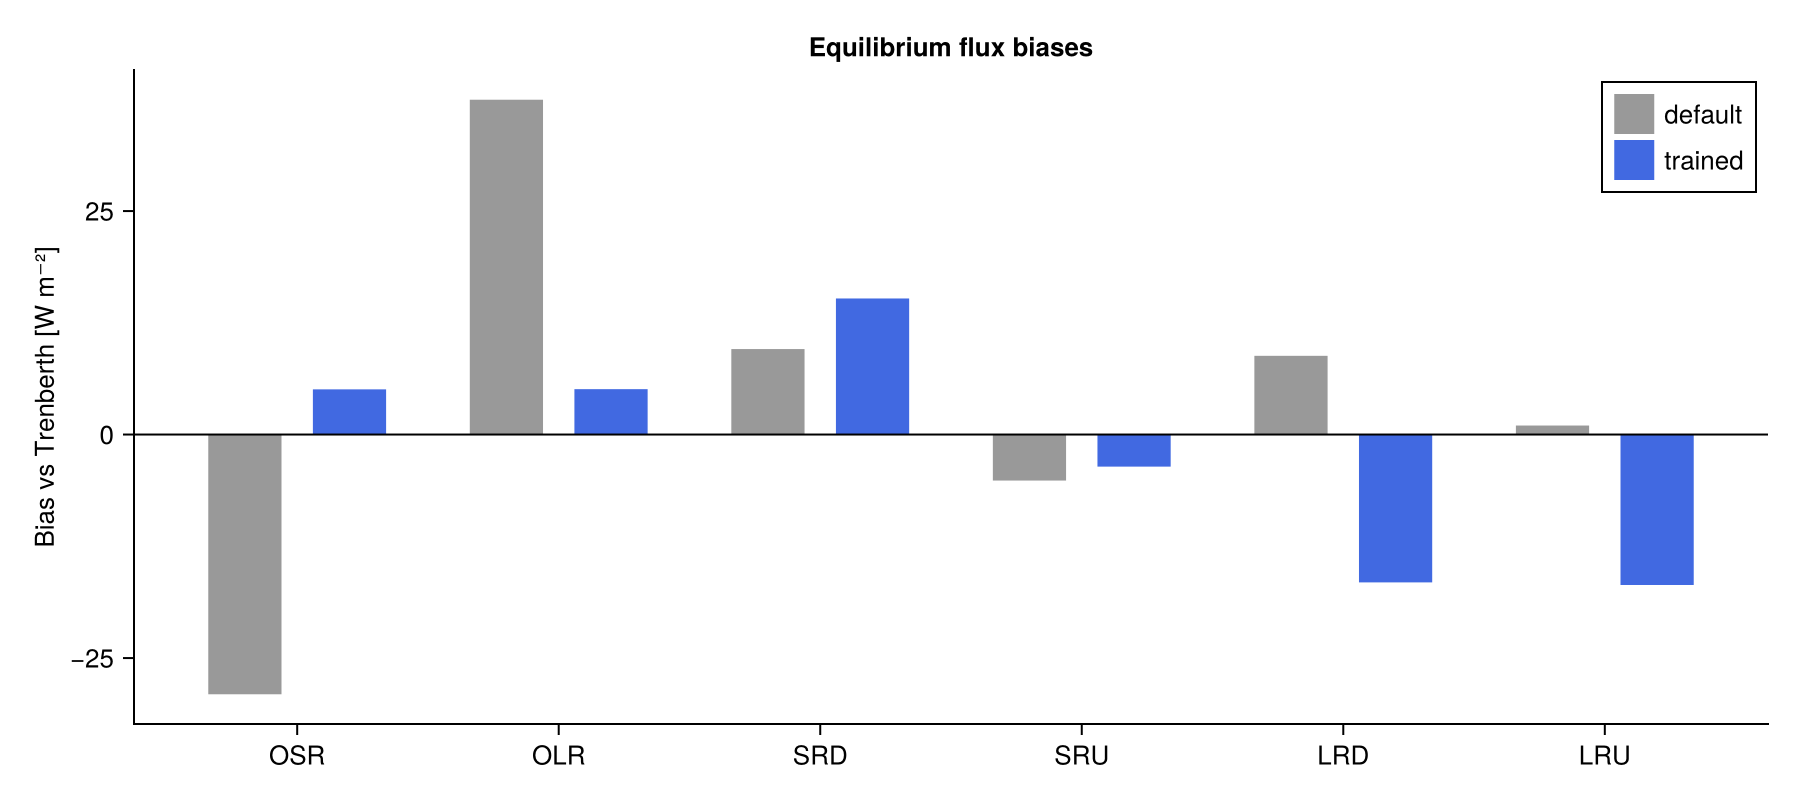

In [26]:
cfigs_eq = plot_climate(clm_eq;
    save_dir    = joinpath(@__DIR__, "output", "cloud_albedo_equal_weights"),
    loss_config = result_eq.loss_config,
)
cfigs_eq.fig_summary

## 11. Comparing Weighted vs. Equal-Weight Loss

Fill in after running:

| | `TRENBERTH_LOSS` (Section 5) | Equal weights (Section 10) |
|---|---|---|
| trained `cloud_albedo` | | |
| best_batch | | |
| best_smoothed_loss | | |
| OSR bias | | |
| SRU bias | | |
| SRD bias | | |
| OLR bias | | |
| LRD bias | | |
| LRU bias | | |

**Questions to answer:**
- Did `cloud_albedo` land on a meaningfully different value under equal weights, or
  roughly the same one? If it barely moved, the weighting scheme isn't what's
  determining the single-parameter optimum — the physical coupling structure
  (cloud_albedo → SW fluxes only) is the dominant constraint, and `TRENBERTH_LOSS`'s
  weights mostly just rescale the reported loss number, not the optimum itself.
- Did the *shape* of the residual floor change — e.g. did SRD/LRD/LRU biases shrink
  (now that they're weighted equally to OSR/OLR) at the cost of a larger OSR bias?
  That would indicate the weights *do* meaningfully steer the trade-off point among
  the SW-reachable terms, even if the LW terms remain structurally unreachable either
  way.
- Is the equal-weight run's training trajectory (Section 10) as stable as the
  weighted one (Section 5), or does removing the down-weighting of noisier surface
  terms (SRD/LRD/LRU) inject more gradient noise and destabilize convergence?